# Midterm: Export Strategy
## Anthony Costanzo
## Friday, March 6th

#### Executive Summary

#### Background Performance

In [ ]:
# Install pandas numpy matplotlib
%pip install pandas numpy matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Problem 3: 
### Conduct growth accounting (1980 - 2019) using the production function with human capital from Assignment/PSet 2 and produce (1) one productivity trajectory graph, and (2) one short interpretation.
#### Variables Required:
- Real GDP (rgdp or cgdpo)
- Capital Stock (rkna or cn)
- Employment or population (emp or pop)
- Human Capital Index (hc)
- Year (year)
#### Formulas Required
- Production function with human capital
- Standard Capital Share (alpha = 0.33)
- A = Y/K^0.33(hL)^0.67
#### Variables to Construct
- Per worker variables: GDP per worker (y = Y/L) and Capital per worker (k = K/L)
- Log TFP

In [ ]:
# Import Packages and Load Data
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [5]:
# Loading Data
pwt = pd.read_csv("/Users/workspace/Desktop/Spring 2026/Code/GLBL 5010/economics-for-global-affairs/midterm/final-pwt.csv")

In [12]:
# Set capital share parameter: A = Y / K^0.33 * (hL)^0.67
alpha = 0.33

def add_series(df, start_year=1980):
    df = df[df["year"] >= start_year].copy()             
    df["y"] = df["rgdpo"] / df["pop"]                    # output per capita (Y/L)
    df["k"] = df["cn"] / df["pop"]                       # capital per capita (K/L)
    df["A"] = df["y"] / (df["k"] ** alpha * df["hc"] ** (1 - alpha))  # TFP residual from production function
    df["lny"] = np.log(df["y"])                          # log output per capita
    df["lnk"] = np.log(df["k"])                          # log capital per capita
    df["lnA"] = np.log(df["A"])                          # log TFP
    return df

In [13]:
# Filter to Taiwan and South Korea and compute time series
pwt_tw = add_series(pwt[pwt["countrycode"] == "TWN"]) # Subset to Taiwan rows and run add_series to compute new columns
pwt_kr = add_series(pwt[pwt["countrycode"] == "KOR"]) # same as above but for South Korea

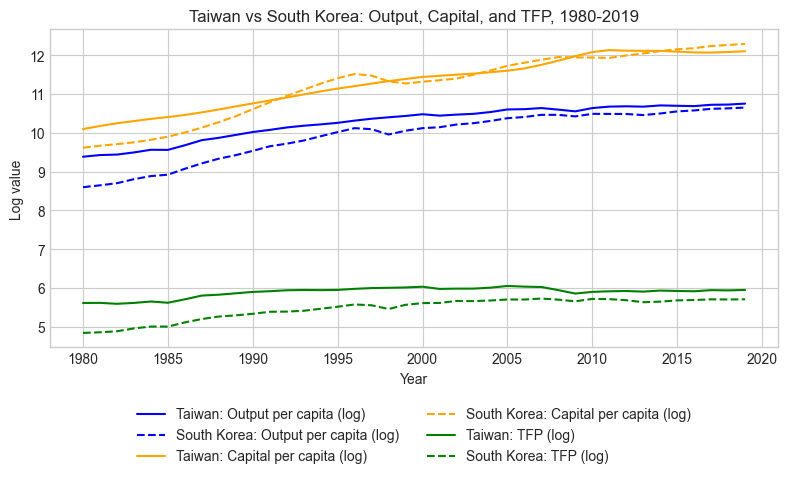

In [18]:
# Variable names, legend labels, and colors
variables = {"lny": "Output per capita (log)", "lnk": "Capital per capita (log)", "lnA": "TFP (log)"} 
colors    = {"lny": "blue", "lnk": "orange", "lnA": "green"}

plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(8, 5))

# Plot each variable for both countries — Taiwan solid, South Korea dashed
for var, label in variables.items():
    plt.plot(pwt_tw["year"], pwt_tw[var], color=colors[var], label=f"Taiwan: {label}")
    plt.plot(pwt_kr["year"], pwt_kr[var], color=colors[var], linestyle="--", label=f"South Korea: {label}")

plt.xlabel("Year")
plt.ylabel("Log value")
plt.title("Taiwan vs South Korea: Output, Capital, and TFP, 1980-2019")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.tight_layout()
plt.show()

Taiwan's strong economic growth from 1980 to 2019 was driven primarily by capital accumulation rather than producivity gains, suggesting that future growth will require a shift toward policies that boost TFP. Over the four-decade period, Taiwan's capital per capita grew substantially, rising from roughly 10 to over 12 log points, while total factor productivity remained nearly flat throughout. This pattern persisted even after Taiwan liberalized in 1987, suggesting that liberilzation was insufficient to shift the economy toward TFP-driven growth. South Korea's trajectory tells a similar story: despite undergoing its own democratic transition the same year, Korea's TFP also stagnated even as its more aggressive capital deepening, visible in its steeper capital trajectory, allowed it to close the output-per-capita gap with Taiwan by 2019. Together, both economies appear to have exhausted the easy gains from adding capital and labor (per Krugman's argument about capital accumulation driving Soviet growth) pointing to the need for policies that directly target allocative efficiency, R&D, and innovation.

## Problem 4a
### Conduct export structure analysis (2000 vs 2022) and compute Revealed Comparative Advantage (RCA). Produce (1) one export/comparative advantage graph, and (2) one short interpretation.
#### Dataset required:
- indflow = pd.read_csv("/Users/workspace/Desktop/Spring 2026/Code/GLBL 5010/economics-for-global-affairs/midterm/final-industryflows.csv")
#### Variables Required:
- Exporter (iso_o)
- Industry code (hs2)
- Year (year)
- Country exports (value)
- World Exports (value_wd)
#### Formulas Required:
- Country total exports
- World total exports
- Country explort share in sector
- World export share in sector
- RCA (Balassa Index[?])
#### Variables to Construct
- Country total exports (by year)
- World total exports (by year)
- Sectoral export share (Taiwan)
- Sectoral world share 
- RCA (by sector, for 2000 and 2022)
- Change in RCA (2022 - 2000)

## Problem 4b
### Estimate gravity model (latest year) to evaluate WTO effect and simulate WTO collapse counterfactual.
#### Dataset required: 
- indflow = pd.read_csv("/Users/workspace/Desktop/Spring 2026/Code/GLBL 5010/economics-for-global-affairs/midterm/final-gravity.csv")
#### Variables Required:
- Export value (value)
- Origin country (iso_o)
- Destination country (iso_d)
- Year (year)
- Distance (distw)
- Destination GDP (gdp_d)
- Shared border (contig)
- Common language (comlang_ethno)
- Common legal system (comleg_posttrans)
- Regional trade agreement (rta)
- WTO membership indicator (wto_d)
#### Formulas Required:
- Log trade (to retain zero flows)
- Log distance
- Log market size
- Gravity specification
#### Counterfactual:
- Predicted export change if WTO collapses (set WTO_d = 0 for all partners and compare predicted values)
#### Vars to construct:
- lvalue
- ldist
- Predicted trade (yhat)
- Counterfactual predicted trade (WTO_d = 0)
